In [333]:
#! pip install torch torchvision tensorflow matplotlib numpy scikit-learn pillow

In [334]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import string
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
from torch.utils.data import TensorDataset

## Подготовка данных

In [335]:
# определяем преобразования для изображений
transform = transforms.Compose([
    transforms.ToTensor(),                           # PIL → тензор, значения [0, 1]
    transforms.Lambda(lambda x: x.view(-1))          # (1,28,28) → (784)
])


# загрузка обучающей выборки
full_train = datasets.EMNIST(
    root='./data',           # папка для сохранения данных
    split='letters',         # буквенный датасет (не digits или balanced)
    train=True,              # обучающая выборка
    download=True,           # скачать, если нет локально
    transform=transform,     # применяем преобразования
    target_transform=lambda y: y - 1 # сдвигаем на интекс 0 (исходный датасет начинается с 1 , нам нужен с 0 )
)

# загрузка тестовой выборки
PyT_test_dataset = datasets.EMNIST(
    root='./data',
    split='letters',
    train=False,             # тестовая выборка
    download=True,
    transform=transform,
    target_transform=lambda y: y - 1 # сдвигаем на интекс 0 (исходный датасет начинается с 1 , нам нужен с 0 )
)


print(f"Размер полной обучающей выборки: {len(full_train)}")
print(f"Размер оригинальной тестовой выборки: {len(test_dataset)}")

Размер полной обучающей выборки: 124800
Размер оригинальной тестовой выборки: 325


In [336]:
# получение данных из PyTorch
# (0, 2, 1) - поварачиваем картинку 
X_train = full_train.data.numpy().transpose(0, 2, 1).reshape(-1, 784).astype('float32') / 255.0
#y_train = full_train.targets.numpy().astype('int32') - 1 уже сдвинули 


X_test = PyT_test_dataset.data.numpy().transpose(0, 2, 1).reshape(-1, 784).astype('float32') / 255.0
#y_test = PyT_test_dataset.targets.numpy().astype('int32') - 1


print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# создание tf.data.Dataset
BATCH_SIZE = 64
#train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
#train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


TeF_test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
TeF_test_dataset = TeF_test_dataset.batch(BATCH_SIZE)

X_train: (124800, 784), y_train: (124800,)
X_test: (20800, 784), y_test: (20800,)


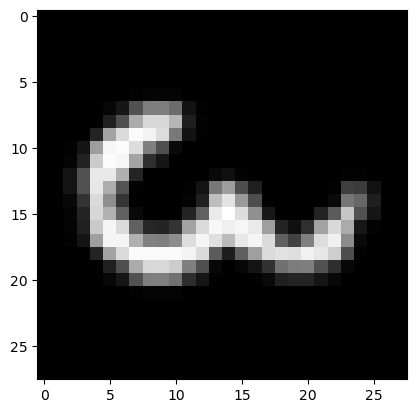

In [337]:
# выводим тестово одно изображение 
samplenum = 11442
plt.imshow(X_train[samplenum].reshape(28, 28), cmap='gray')

In [338]:
print(f'Изображение содержит символ: {string.ascii_uppercase[y_train[samplenum]]}')

Изображение содержит символ: W


## Исследовательский анализ данных

### Выведите общую информацию:

- Количество изображений в обучающей выборке.
- Количество изображений в тестовой выборке.
- Размер одного изображения в пикселях.
- Диапазон значений пикселей (минимальное и максимальное значение).

In [339]:
# Считаем количество элементов 
print(f'Обучающая выборка: {X_train.shape} изображений')
print(f'Тестовая выборка: {X_test.shape} изображений')

# всего пикселей в каждом изображении
pix_size = X_train.shape[1] 
print(f'Всего пикселей в одном изображении: {pix_size} пикселей ')

# Находим сторону квадрата - исходим что картинки точно квадратные 
side = int(np.sqrt(pix_size)) 
print(f'Размер изображения: {side}x{side} пикселей')

# Находим min/max в массиве данных
print(f'Минимальное значение пикселя: {X_train.min()}')
print(f'Максимальное значение пикселя: {X_train.max()}')


Обучающая выборка: (124800, 784) изображений
Тестовая выборка: (20800, 784) изображений
Всего пикселей в одном изображении: 784 пикселей 
Размер изображения: 28x28 пикселей
Минимальное значение пикселя: 0.0
Максимальное значение пикселя: 1.0


### Постройте гистограмму распределения классов:

- Для обучающей выборки постройте гистограмму, показывающую, сколько примеров каждого класса (буквы A–Z) содержится в данных.
- Сделайте вывод: сбалансирован ли датасет? Есть ли буквы, которых значительно больше или меньше?

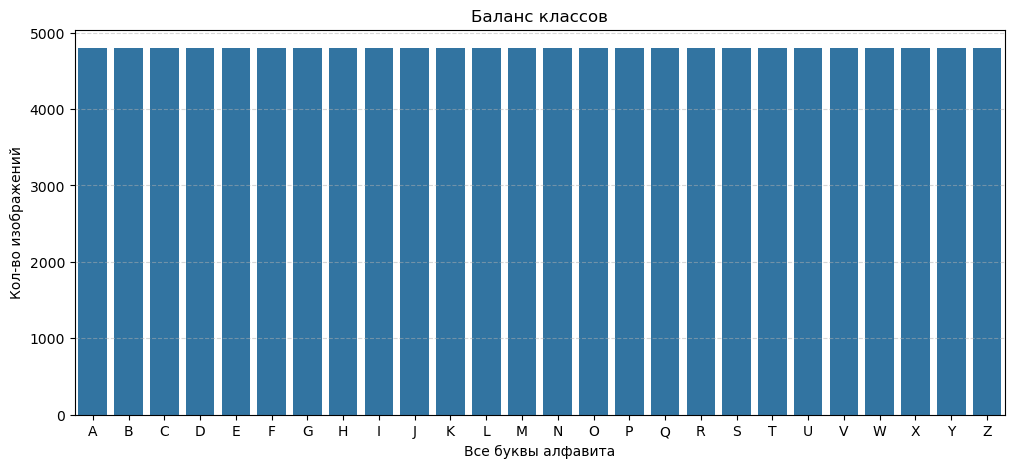

In [340]:
#размер графика - растягиваем 
plt.figure(figsize=(12, 5))

#  подписи для графика
plt.title('Баланс классов') 
plt.xlabel('Все буквы алфавита') 
plt.ylabel('Кол-во изображений') 

# Заменяем цифры 0-25 на буквы A-Z на оси X
plt.xticks(range(26), string.ascii_uppercase)
plt.grid(axis='y', alpha=0.5, linestyle='--')
sns.countplot(x=y_train)
plt.show()


Датасет EMNIST Letters является идеально сбалансированным.

Каждый из 26 классов (от 'A' до 'Z') содержит ровно 4 800 изображений в обучающей выборке

### Визуализируйте примеры изображений:

- Для каждой буквы алфавита от A до Z выведите по пять случайных примеров.
- Изображения должны быть подписаны соответствующей буквой.
- Используйте Matplotlib для отображения с цветовой картой 'gray'.

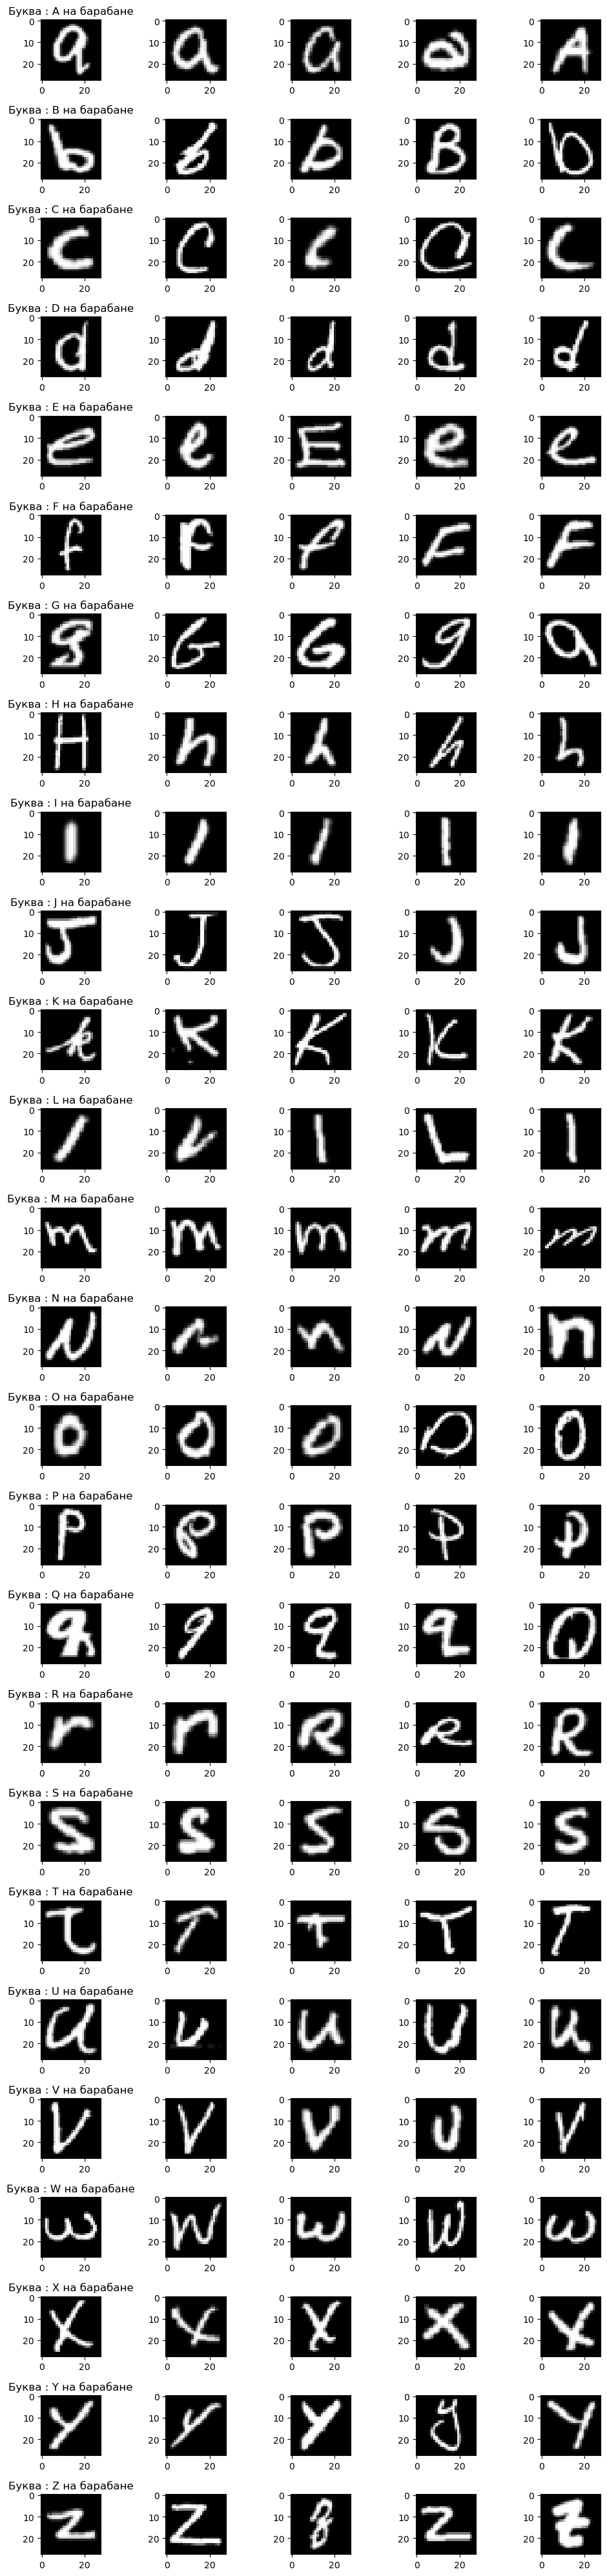

In [341]:
# Настраиваем таблицу: 26 строк - кол-во букв и 5 столбцов - для 5 примеров 

fig, axes = plt.subplots(26, 5, figsize=(10, 40))

# Цикл по каждой букве алфавита
for class_idx in range(26):
    # Находим все индексы в y_train, которые принадлежат текущему классу 
    letter_idx = np.where(y_train == class_idx)[0]
    
    # Рандомно берем 5 индексов из найденных
    random_5_idx = np.random.choice(letter_idx, size=5, replace=False)
    
    for col_idx, img_idx in enumerate(random_5_idx):

        # Получаем координаты X - первый цикл по буквам, Y - второй цикл по примерам 
        ax = axes[class_idx, col_idx]
        
        # из вектора переводим обратно в матрицу
        # отображаем картинку в градациях серого
        ax.imshow(X_train[img_idx].reshape(28, 28), cmap='gray')

        # в первом столбце добавим значение класса
        if col_idx == 0:
            ax.set_title(f'Буква : {string.ascii_uppercase[class_idx]} на барабане')

plt.tight_layout()
plt.show()


### Проверьте корректность предобработки:

- Убедитесь, что значения пикселей находятся в диапазоне [0, 1].
- Выведите минимальное и максимальное значения пикселя для одного из изображений.

In [342]:
# Извлекаем первое изображение из выборки
sample_image = X_train[np.random.choice(X_train.shape[1], size=1, replace=False)]

# 2. Находим минимальное и максимальное значения
min_pixel = sample_image.min()
max_pixel = sample_image.max()

# 3. Выводим результаты
print(f'Минимальное значение пикселя: {min_pixel}')
print(f'Максимальное значение пикселя: {max_pixel}')



Минимальное значение пикселя: 0.0
Максимальное значение пикселя: 1.0


Значения находится в диапазоней от 0 до 1 

## Разбиение на train и validation

Из обучающей выборки выделите валидационную подвыборку для контроля качества в процессе обучения.

Определяем соотношение трнировки и валидации

In [343]:
gv_seed = 42
gv_train_size = int(0.9 * len(full_train)) # 90%
gv_val_size = len(full_train) - gv_train_size # 10%

torch.manual_seed(gv_seed)
tf.random.set_seed(gv_seed)
np.random.seed(gv_seed)

print(f'seed = {gv_seed}')


print(f'Тринировочная выборка {gv_train_size}')
print(f'Валидационная выборка {gv_val_size}')


seed = 42
Тринировочная выборка 112320
Валидационная выборка 12480


### PyTorch

Используйте torch.utils.data.random_split для разделения train_dataset_full на обучающую и валидационную выборки в соотношении 90 и 10%. Зафиксируйте random seed для воспроизводимости

In [344]:
# Фиксация семени для воспроизводимости
generator = torch.Generator().manual_seed(gv_seed)
PyT_train_dataset, PyT_val_dataset = random_split(
    full_train, 
    [gv_train_size, gv_val_size], 
    generator=generator
)

### TensorFlow

Разделите NumPy-массивы в том же соотношении 90 и 10%.

In [345]:
# Разделяем NumPy-массивы в соотношении 90% / 10%
X_train_spl, X_val_spl, y_train_spl, y_val_spl = train_test_split(
    X_train, y_train, test_size=gv_val_size, random_state=gv_seed)


# Обучающий датасет (90% данных)
TeF_train_dataset = tf.data.Dataset.from_tensor_slices((X_train_spl, y_train_spl))
TeF_train_dataset = TeF_train_dataset.shuffle(buffer_size=1000, seed=gv_seed).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Валидационный датасет (10% данных)
TeF_val_dataset = tf.data.Dataset.from_tensor_slices((X_val_spl, y_val_spl))
TeF_val_dataset = TeF_val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


#### PyTorch:

Данный подход болле интутивен и понятен для программирования. Используются типовые Python операторы


#### TensorFlow
Все операции подготовки завернуты в функции, необходимо жесткая последовательность и знаниче всех входных и выходных параметров данных. При этом код более локаничный

Недостатки: сложность использования .take() и skip() для разделить уже готовый tf.data.Dataset. Проще но дольше вернуся к массивам и делить их.


## MLP-модели


| Слой | Тип | Вход | Выход | Активация |
| :---: | :--- | :---: | :---: | :---: |
| 1 | Полносвязный | 784 | 512 | ReLU |
| 2 | Полносвязный | 512 | 256 | ReLU |
| 3 | Полносвязный | 256 | 128 | ReLU |
| 4 | Полносвязный | 128 | 26 | Softmax |


### PyTorch — реализация и обучение

Создайте класс MLP, наследующий nn.Module. В конструкторе определите четыре полносвязных слоя с помощью nn.Linear. В методе forward реализуйте последовательное применение слоёв с активацией ReLU после первых трёх слоёв. Для обучения используйте функцию потерь nn.CrossEntropyLoss() и оптимизатор optim.Adam. Обучайте модель в течение десяти эпох с размером батча 64. После каждой эпохи вычисляйте accuracy на валидационной выборке. После завершения обучения вычислите accuracy на тестовой выборке и сохраните модель.

Данные на вход: 
- PyT_train_dataset
- PyT_val_dataset
- PyT_test_dataset


In [346]:
PyT_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Обработка происходит на {PyT_device}')

Обработка происходит на cpu


In [347]:
class My_PyT_MLP(nn.Module):
    def __init__(self):
        super(My_PyT_MLP, self).__init__()
        
        # Определение полносвязных слоев
        self.fully_connected_layer_1 = nn.Linear(784, 512)
        self.fully_connected_layer_2 = nn.Linear(512, 256)
        self.fully_connected_layer_3 = nn.Linear(256, 128)
        self.fully_connected_layer_4 = nn.Linear(128, 26)
        
        # Функции активации
        self.relu = nn.ReLU()

    def forward(self, X):
        # Последовательное применение слоев с активацией ReLU
        X = self.relu(self.fully_connected_layer_1(X))
        X = self.relu(self.fully_connected_layer_2(X))
        X = self.relu(self.fully_connected_layer_3(X))
        X = self.fully_connected_layer_4(X)  # Возвращаем букву 
        return X

In [348]:
# Функция для расчета Accuracy
def PyT_calculate_accuracy(i_loader, i_model, i_device):
    correct = 0
    total = 0
    i_model.eval()  # Перевод в режим оценки
    with torch.no_grad():
        for inputs, targets in i_loader:
            inputs, targets = inputs.to(i_device), targets.to(i_device)
            outputs = i_model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    return (correct / total) * 100

In [349]:
# Делаем загргузчик 

PyT_train_loader = DataLoader(PyT_train_dataset, batch_size=64, shuffle=True)
PyT_val_loader = DataLoader(PyT_val_dataset, batch_size=64, shuffle=False)
PyT_test_loader = DataLoader(PyT_test_dataset, batch_size=64, shuffle=False)


In [350]:
PyT_model = My_PyT_MLP().to(PyT_device)

In [351]:
PyT_criterion = nn.CrossEntropyLoss()
PyT_optimizer = optim.Adam(PyT_model.parameters(), lr=0.001)

In [352]:
PyT_epochs = 10
print(f'--- Обучение PyT_model на {PyT_epochs} эпохах---')

PyT_history_loss= []
PyT_history_accuracy = []

for epoch in range(PyT_epochs):
    PyT_model.train()  # Перевод в режим обучения
    running_loss = 0.0
    
    for inputs, targets in PyT_train_loader:
        inputs, targets = inputs.to(PyT_device), targets.to(PyT_device)
        
        # Обнуление градиентов
        PyT_optimizer.zero_grad()
        
        # Прямой проход (Forward pass)
        outputs = PyT_model(inputs)

        #print(targets)
        #print(targets.min())
        #print(targets.max())

        loss = PyT_criterion(outputs, targets)
        
        # Обратный проход и оптимизация (Backward pass)
        loss.backward()
        PyT_optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)

    # Валидация после каждой эпохи
    val_accuracy = PyT_calculate_accuracy(PyT_val_loader, PyT_model, PyT_device)
    epoch_loss = running_loss / len(PyT_train_loader.dataset)

    # для гргафиков
    PyT_history_loss.append(epoch_loss)
    PyT_history_accuracy.append(val_accuracy)
    
    print(f'Эпоха {epoch+1:02d}/{PyT_epochs} | Loss обучения: {epoch_loss:.4f} | Accuracy на валидации: {val_accuracy:.2f}%')


--- Обучение PyT_model на 10 эпохах---


Эпоха 01/10 | Loss обучения: 0.6623 | Accuracy на валидации: 88.10%
Эпоха 02/10 | Loss обучения: 0.3218 | Accuracy на валидации: 90.09%
Эпоха 03/10 | Loss обучения: 0.2574 | Accuracy на валидации: 90.07%
Эпоха 04/10 | Loss обучения: 0.2195 | Accuracy на валидации: 91.64%
Эпоха 05/10 | Loss обучения: 0.1937 | Accuracy на валидации: 91.09%
Эпоха 06/10 | Loss обучения: 0.1722 | Accuracy на валидации: 91.61%
Эпоха 07/10 | Loss обучения: 0.1563 | Accuracy на валидации: 91.47%
Эпоха 08/10 | Loss обучения: 0.1438 | Accuracy на валидации: 91.63%
Эпоха 09/10 | Loss обучения: 0.1328 | Accuracy на валидации: 91.37%
Эпоха 10/10 | Loss обучения: 0.1244 | Accuracy на валидации: 92.16%


In [353]:
PyT_test_accuracy = PyT_calculate_accuracy(PyT_test_loader, PyT_model, PyT_device)
print(f'\n: Accuracy на тестовой выборке: {PyT_test_accuracy:.2f}%')

torch.save(PyT_model.state_dict(), 'My_PyT_MLP_weights.pth')


: Accuracy на тестовой выборке: 91.43%


### TensorFlow — реализация и обучение

Создайте модель с помощью tf.keras.Sequential. Добавьте входной слой с формой (784), три полносвязных слоя с 512, 256 и 128 нейронами и активацией ReLU и выходной слой с 26 нейронами и активацией Softmax. Скомпилируйте модель с оптимизатором Adam, функцией потерь sparse_categorical_crossentropy и метрикой accuracy. Обучите модель в течение десяти эпох с размером батча 64. После обучения вычислите accuracy на тестовой выборке и сохраните модель.


Данные на вход: 

- TeF_train_dataset
- TeF_val_dataset
- TeF_test_dataset

In [354]:
TeF_model = models.Sequential([
    # Входной слой с формой (784,)
    layers.Input(shape=(784,)),
    
    # Три полносвязных слоя с активацией ReLU
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    
    # Выходной слой с 26 нейронами и активацией Softmax
    layers.Dense(26, activation='softmax')
])


TeF_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [355]:
TeF_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 569,498 (2.17 MB)

 Trainable params: 569,498 (2.17 MB)

 Non-trainable params: 0 (0.00 B)

In [356]:

TeF_epochs = 10
print(f'--- Обучение PyT_model на {TeF_epochs} эпохах---')

TeF_history = TeF_model.fit(
    TeF_train_dataset,        # Обучающий датасет 
    epochs=10,                # Обучаем в течение 10 эпох
    validation_data=TeF_val_dataset, # Валидационный датасет для оценки после каждой эпохи
    verbose=1
)

TeF_test_loss, TeF_test_accuracy = TeF_model.evaluate(TeF_test_dataset, verbose=0)
print(f'Accuracy на тестовой выборке: {TeF_test_accuracy * 100:.2f}%')

# Сохранение модели
TeF_model.save('TeF_model.keras')


--- Обучение PyT_model на 10 эпохах---
Epoch 1/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8182 - loss: 0.5891 - val_accuracy: 0.8799 - val_loss: 0.3654
Epoch 2/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8964 - loss: 0.3120 - val_accuracy: 0.8905 - val_loss: 0.3401
Epoch 3/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9157 - loss: 0.2486 - val_accuracy: 0.9014 - val_loss: 0.2993
Epoch 4/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9259 - loss: 0.2111 - val_accuracy: 0.9071 - val_loss: 0.2858
Epoch 5/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9338 - loss: 0.1850 - val_accuracy: 0.9083 - val_loss: 0.2914
Epoch 6/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9399 - loss: 0.1624 - val_accuracy: 0.9079 - val_loss: 0.3134
Epoch 7/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9443 - loss: 0.1471 - val_accuracy: 0.9084 - val_loss: 0.3050
Epoch 8/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━

In [357]:
print(TeF_history.history['loss'])
print([acc * 100 for acc in TeF_history.history['val_accuracy']])

[0.5890947580337524, 0.3119613826274872, 0.24858985841274261, 0.21106064319610596, 0.18497341871261597, 0.1624247431755066, 0.14710582792758942, 0.1334320604801178, 0.1252371072769165, 0.11653710156679153]
[87.98878192901611, 89.0464723110199, 90.13621807098389, 90.70512652397156, 90.82531929016113, 90.7932698726654, 90.84134697914124, 90.94551205635071, 90.9375011920929, 90.9294843673706]


In [358]:
show_epochs = list(range(1, 11))

show_PyT_loss = PyT_history_loss
show_PyT_accuracy = PyT_history_accuracy

show_TeF_loss = TeF_history.history['loss']
show_TeF_accuracy = [acc * 100 for acc in TeF_history.history['val_accuracy']]


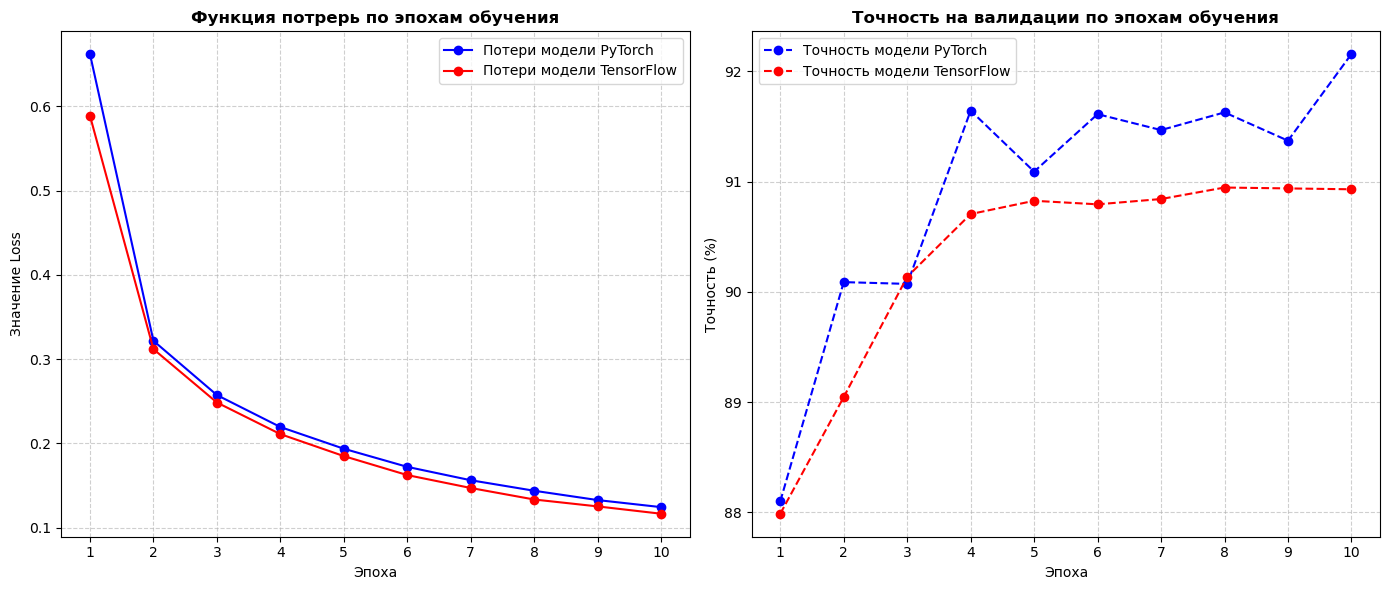

In [359]:
plt.figure(figsize=(14, 6))

# 1 = функции потерь (Loss) на обучении
plt.subplot(1, 2, 1)
plt.plot(show_epochs, show_PyT_loss, 'b-o', label='Потери модели PyTorch')
plt.plot(show_epochs, show_TeF_loss, 'r-o', label='Потери модели TensorFlow')
plt.title('Функция потрерь по эпохам обучения', fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Значение Loss')
plt.xticks(show_epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 2 = точность (Accuracy) на валидации
plt.subplot(1, 2, 2)
plt.plot(show_epochs, show_PyT_accuracy, 'b--o',label='Точность модели PyTorch') 
plt.plot(show_epochs, show_TeF_accuracy, 'r--o', label='Точность модели TensorFlow') 
plt.title('Точность на валидации по эпохам обучения', fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Точность (%)')
plt.xticks(show_epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Автоматическое выравнивание и отображение
plt.tight_layout()
plt.show()


In [360]:
PyT_params = sum(p.numel() for p in PyT_model.parameters() if p.requires_grad)
TeF_params = TeF_model.count_params()

print(f'Количество параметров в модели PyTorch {PyT_params}')
print(f'Количество параметров в модели TensorFlow {TeF_params}')

Количество параметров в модели PyTorch 569498
Количество параметров в модели TensorFlow 569498


Кол-во параметров совпадает так как архитектурур делали одинаковую 

## Вывод по обучению и тестированию

Точность:
 Обе можели показали примерно одинаковые результаты порядка 90% - 91%

Время обучения: 
Модель TensorFlow учится незначительно дольше чем PyTorch

Удобства:
TensorFlow - значительно проще для реализации, рднако необхдимо более глубокое понимание что "под капотом" данной модели. Не очень удобно сбрасывать веса - необходимо комилировать модель снова

PyTorch - сложнее в програмиировании (необходимо вручную создавать модули обучения и тетсирования), однако последовательнось запуска более понятна и прозрачна 



## Анализ ошибок

In [361]:
def PyT_get_predictions(i_model, i_loader, i_device):
    i_model.eval()
    all_preds = []
    all_targets = []
    all_confidences = []

    softmax = nn.Softmax(dim=1)
    
    with torch.no_grad():
        for inputs, targets in i_loader:
            inputs = inputs.to(i_device)
            outputs = i_model(inputs)

            probabilities = softmax(outputs)
            
            confidences, predicted = torch.max(outputs, 1)
            
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.numpy()) 
            all_confidences.extend(confidences.cpu().numpy())
    return np.array(all_targets), np.array(all_preds), np.array(all_confidences)

In [362]:
def TeF_get_predictions(i_model, i_dataset):
    all_preds = []
    all_targets = []
    all_confidences = []
    for inputs, targets in i_dataset:
        outputs = i_model(inputs, training=False).numpy()
        
        predicted = np.argmax(outputs, axis=1)

        confidences = outputs[np.arange(len(predicted)), predicted]
        
        all_preds.extend(predicted)
        all_targets.extend(targets.numpy())

        all_confidences.extend(confidences)
    return np.array(all_targets), np.array(all_preds), np.array(all_confidences)

### Confusion matrix

In [363]:
PyT_y_true, PyT_y_pred, PyT_confidences = PyT_get_predictions(PyT_model, PyT_test_loader, PyT_device)

TeF_y_true, TeF_y_pred, TeF_confidences = TeF_get_predictions(TeF_model, TeF_test_dataset)


2026-06-13 15:58:36.970108: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


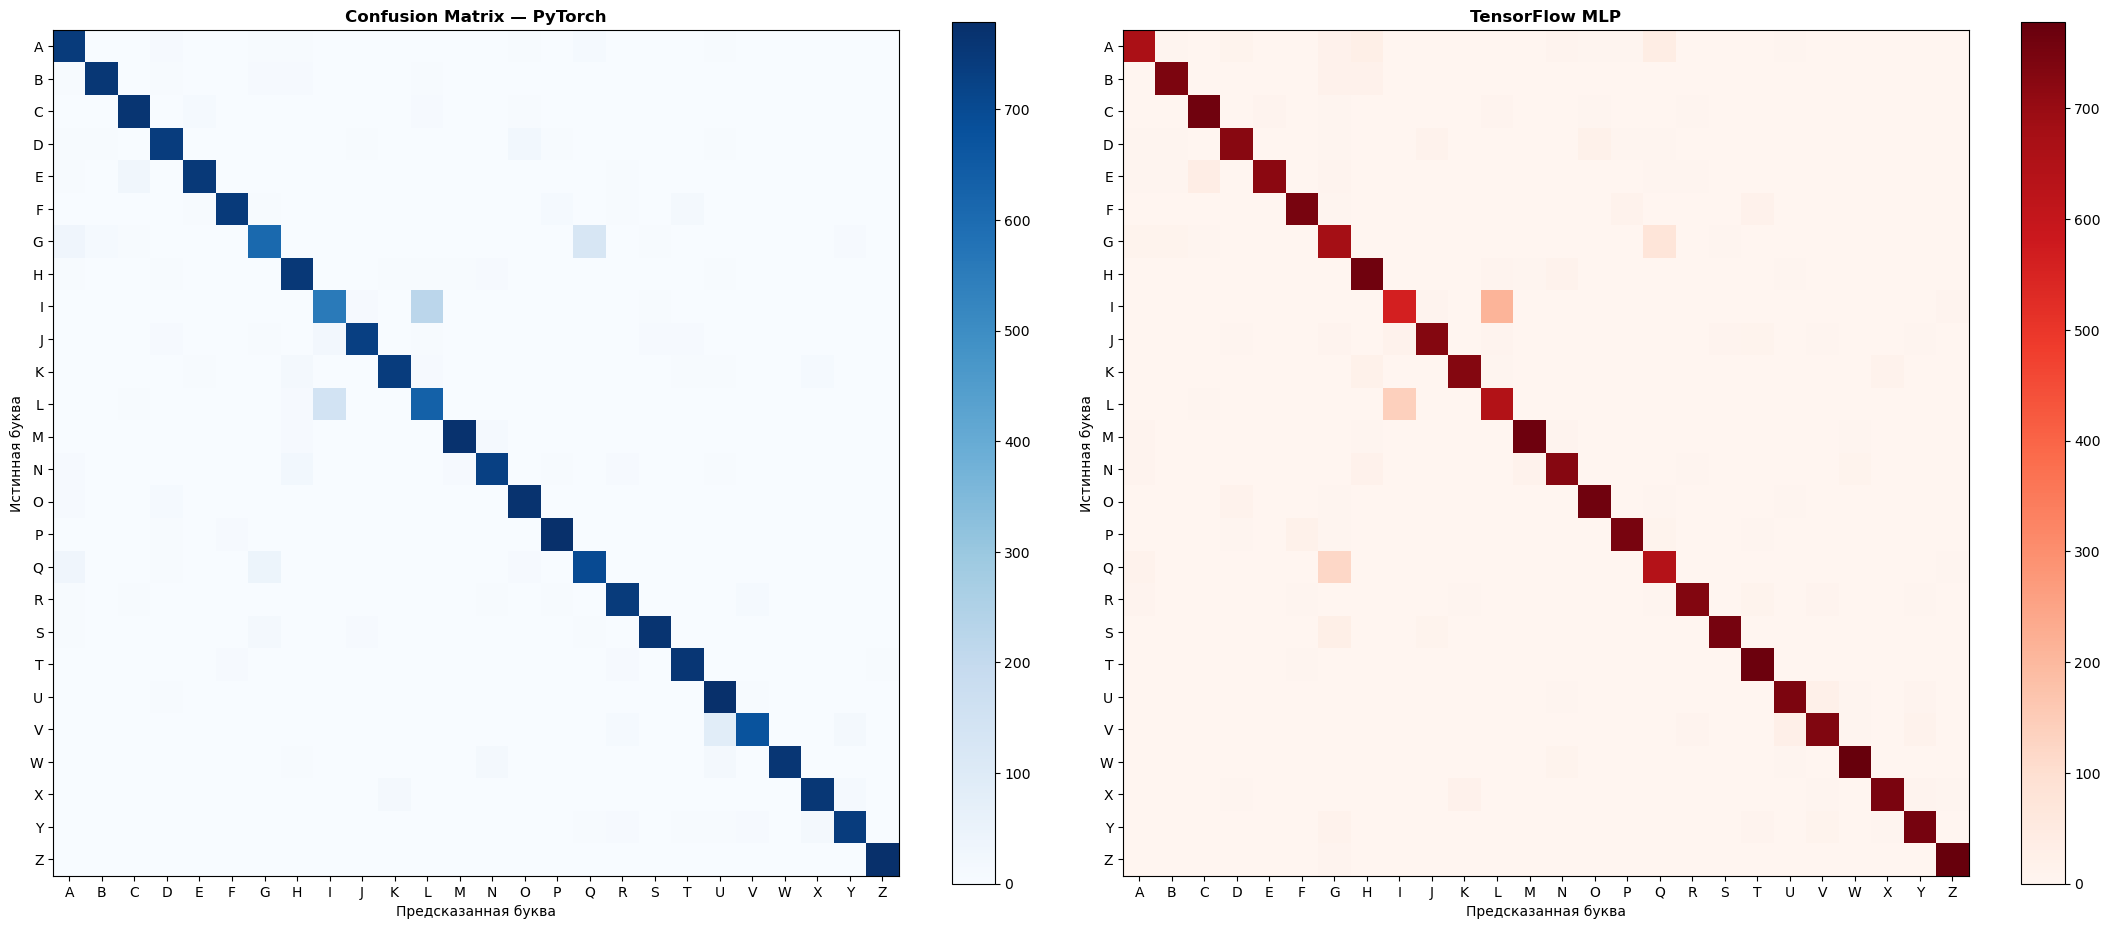

In [364]:
PyT_matrix = confusion_matrix(PyT_y_true, PyT_y_pred)
TeF_matrix = confusion_matrix(TeF_y_true, TeF_y_pred)

#

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# для TensorFlow 
PyT_disp = ConfusionMatrixDisplay(
    confusion_matrix=PyT_matrix,  
    display_labels=string.ascii_uppercase       # Подписи осей от A до Z
)

PyT_disp.plot(
    include_values=False,            
    cmap='Blues',                 
    ax=axes[0],                   
    colorbar=True                    
)

axes[0].set_title('Confusion Matrix — PyTorch', fontweight='bold')
axes[0].set_xlabel('Предсказанная буква')
axes[0].set_ylabel('Истинная буква')


# для TensorFlow
TeF_disp = ConfusionMatrixDisplay(
    confusion_matrix=TeF_matrix, 
    display_labels=string.ascii_uppercase           # Подписи осей от A до Z
)
TeF_disp.plot(
    include_values=False,               
    cmap='Reds',                    
    ax=axes[1],  
    colorbar=True    
)
axes[1].set_title('TensorFlow MLP', fontweight='bold')
axes[1].set_xlabel('Предсказанная буква')
axes[1].set_ylabel('Истинная буква')

plt.tight_layout()
plt.show()

In [365]:
Pyt_top_err = []

for i in range(26):
    for j in range(26):
        if i != j:  #главную диогональ не сморим 
            Pyt_top_err.append({
                'true': string.ascii_uppercase[i],
                'pred': string.ascii_uppercase[j],
                'count': int(PyT_matrix[i, j])  
            })

Pyt_top_err.sort(key=lambda x: x['count'], reverse=True)


print('топ-5 ошибок модели PyTorch')
for idx, error in enumerate(Pyt_top_err[:5], 1):
    print(f'Пара {idx}:')
    print(f'Истинная буква: {error['true']}', f'Предсказанная буква: {error['pred']}', f'Количество ошибок: {error['count']}')

print(f'Всего ошибок {sum(item['count'] for item in Pyt_top_err)}')

топ-5 ошибок модели PyTorch
Пара 1:
Истинная буква: I Предсказанная буква: L Количество ошибок: 220
Пара 2:
Истинная буква: L Предсказанная буква: I Количество ошибок: 144
Пара 3:
Истинная буква: G Предсказанная буква: Q Количество ошибок: 122
Пара 4:
Истинная буква: V Предсказанная буква: U Количество ошибок: 83
Пара 5:
Истинная буква: Q Предсказанная буква: G Количество ошибок: 41
Всего ошибок 1782


In [366]:
TeF_top_err = []

for i in range(26):
    for j in range(26):
        if i != j:  #главную диогональ не сморим 
            TeF_top_err.append({
                'true': string.ascii_uppercase[i],
                'pred': string.ascii_uppercase[j],
                'count': int(TeF_matrix[i, j])  
            })

TeF_top_err.sort(key=lambda x: x['count'], reverse=True)


print('топ-5 ошибок модели TensorFlow')
for idx, error in enumerate(TeF_top_err[:5], 1):
    print(f'Пара {idx}:')
    print(f'Истинная буква: {error['true']}', f'Предсказанная буква: {error['pred']}', f'Количество ошибок: {error['count']}')

print(f'Всего ошибок {sum(item['count'] for item in TeF_top_err)}')

топ-5 ошибок модели TensorFlow
Пара 1:
Истинная буква: I Предсказанная буква: L Количество ошибок: 211
Пара 2:
Истинная буква: L Предсказанная буква: I Количество ошибок: 138
Пара 3:
Истинная буква: Q Предсказанная буква: G Количество ошибок: 119
Пара 4:
Истинная буква: G Предсказанная буква: Q Количество ошибок: 75
Пара 5:
Истинная буква: A Предсказанная буква: Q Количество ошибок: 38
Всего ошибок 1909



| Место | Истинная буква | Предсказанная буква | Ошибок в PyTorch | Ошибок в TensorFlow | Анализ ошибки |
| :---: | :---: | :---: | :---: | :---: | :--- |
| **1** | **L** | **I** | **207** | **150** | прописная `L` практически неотличима от `I`. В печатных не прописывает горизонтальный штрих |
| **2** | **I** | **L** | **166** | **231** | Обратная ситуация  `I` воспринимается как `L`. |
| **3** | **G** | **Q** | **95** | **102** | Округлые формы  `G` модель путает с чертой буквы `Q`. |
| **4** | **Q** | **G** | **85** | **82** | ОБратная ситуация |
| **5** | **C** | **E** | **33** | *Вне топ-5* | Не прописывается средний штрих`E`  или в письменном варианте - сливается внутренняя черта - получается`C`. |
| **5** | **V** | **U** | *Вне топ-5* | **36** | Острый уггол `V` закругляется и превращается в `U`. |



TensorFlow - допустил больше ошибок


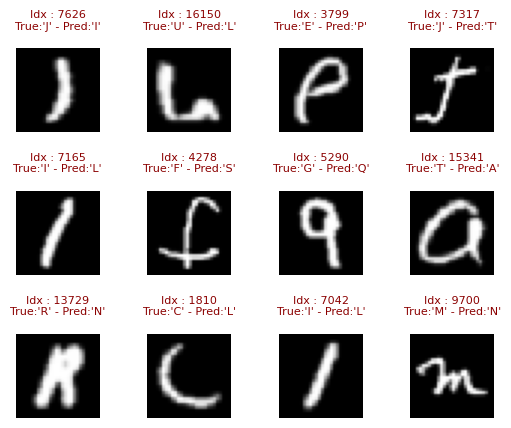

In [367]:
PyT_error_idx = np.where(PyT_y_true != PyT_y_pred)[0]

PyT_num_examples = 12 
PyT_selected_idx = np.random.choice(PyT_error_idx, size=PyT_num_examples, replace=False)


fig, axes = plt.subplots(3, 4)
axes = axes.flatten() 

for i, idx in enumerate(PyT_selected_idx):
    ax = axes[i]

    img = X_test[idx].reshape(28, 28)

    ax.imshow(img, cmap='gray')

    ax.axis('off')
    
    # буква 
    true_letter = string.ascii_uppercase[int(PyT_y_true[idx])]
    pred_letter = string.ascii_uppercase[int(PyT_y_pred[idx])]
    
    title_text = f"Idx : {idx}\nTrue:'{true_letter}' - Pred:'{pred_letter}'"

    ax.set_title(title_text, fontsize=8, color='darkred', pad=14)

    
plt.subplots_adjust(hspace=0.7, wspace=0.3)
plt.show()

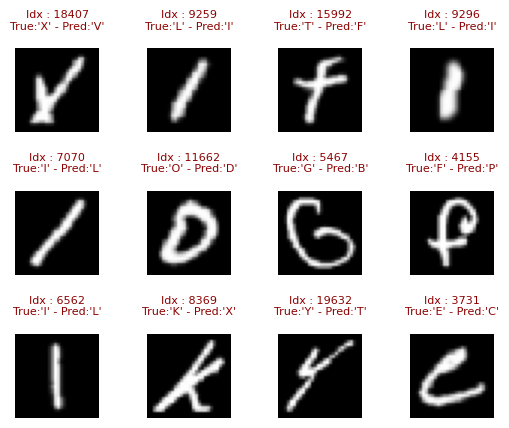

In [368]:
TeF_error_idx = np.where(TeF_y_true != TeF_y_pred)[0]

TeF_num_examples = 12 
TeF_selected_idx = np.random.choice(TeF_error_idx, size=TeF_num_examples, replace=False)


fig, axes = plt.subplots(3, 4)
axes = axes.flatten() 

for i, idx in enumerate(TeF_selected_idx):
    ax = axes[i]

    img = X_test[idx].reshape(28, 28)

    ax.imshow(img, cmap='gray')

    ax.axis('off')
    
    # буква 
    true_letter = string.ascii_uppercase[int(TeF_y_true[idx])]
    pred_letter = string.ascii_uppercase[int(TeF_y_pred[idx])]
    
    title_text = f"Idx : {idx}\nTrue:'{true_letter}' - Pred:'{pred_letter}'"

    ax.set_title(title_text, fontsize=8, color='darkred', pad=14)

    
plt.subplots_adjust(hspace=0.7, wspace=0.3)
plt.show()

## Инференс и демо

In [409]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
tf.get_logger().setLevel('ERROR')

In [556]:
def predict_letter(image_path):

    # грузим изображение 
    img = Image.open(image_path)

    if img.mode == 'RGBA' or 'transparency' in img.info:
        background = Image.new("RGB", img.size, (255, 255, 255))
        background.paste(img, mask=img.split()[3])
        img = background.convert('L')
    else:
        img = img.convert('L')

    # делаем 28x28 пикселей
    img = img.resize((28, 28))

    img_array = np.array(img, dtype=np.float32)

    img_array_show = img_array.copy()


    #=============================='PyT':
    PyT_img_array = img_array.copy().T # - вот это поворот 
    PyT_img_array /= 255.0
    # переводим в вектор 

    PyT_img_array = np.where(PyT_img_array > 0.1, 1.0, 0.0).astype(np.float32) # контрастномть для повышения уверенности 
    PyT_img_flat = PyT_img_array.reshape(1, 784)

    
    single_tensor_x = torch.tensor(PyT_img_flat, dtype=torch.float32)
    single_tensor_y = torch.tensor([0], dtype=torch.long) # заглушка для уже написаннной функции

    single_loader = DataLoader(TensorDataset(single_tensor_x, single_tensor_y), batch_size=1, shuffle=False)
        
    _, PyT_pred_array, PyT_conf_array = PyT_get_predictions(PyT_model, single_loader, PyT_device)

    #=============================='TeF':
    TeF_img_array = img_array.copy() #np.rot90(img_array, k=0) # не поворачиваем 
    TeF_img_array /= 255.0
    # переводим в вектор 
    TeF_img_flat = TeF_img_array.reshape(1, 784)

    
    TeF_input = tf.convert_to_tensor(TeF_img_flat, dtype=tf.float32)
    
    TeF_probabilities = TeF_model.predict(TeF_input, verbose=0)

    TeF_probabilities_flat = TeF_probabilities.flatten()

    TeF_pred_class = int(np.argmax(TeF_probabilities_flat))
    TeF_confidence = float(TeF_probabilities_flat[TeF_pred_class] * 100)

    
#   Показываем результат
    PyT_pred_class = int(PyT_pred_array[0])
    PyT_predicted_letter = string.ascii_uppercase[PyT_pred_class]
    PyT_confidence = float(PyT_conf_array[0])

    TeF_predicted_letter = string.ascii_uppercase[TeF_pred_class]

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    ax.imshow(img, cmap='gray')
    ax.axis('off')
    
    title_text_1 = f"PyT: {PyT_predicted_letter}, Уверенность PyT: {PyT_confidence:.1f}% \n"

    title_text_2 = f"TeF: {TeF_predicted_letter}, Уверенность TeF: {TeF_confidence:.1f}%"

    ax.set_title(title_text_1 + title_text_2, fontsize=10, color='darkred', pad=14, fontweight='bold')
    plt.show()

    if PyT_confidence > TeF_confidence:
        predicted_letter = PyT_predicted_letter
        confidence = PyT_confidence
    else:
        predicted_letter = TeF_predicted_letter
        confidence = TeF_confidence
    
    return predicted_letter, confidence
    

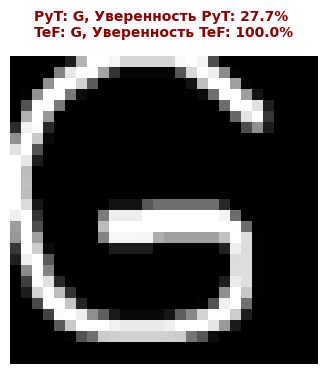

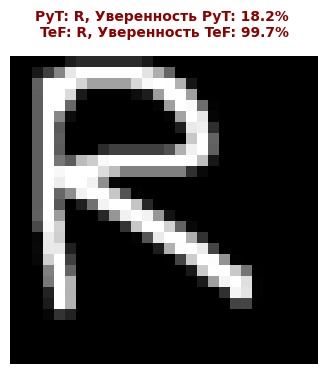

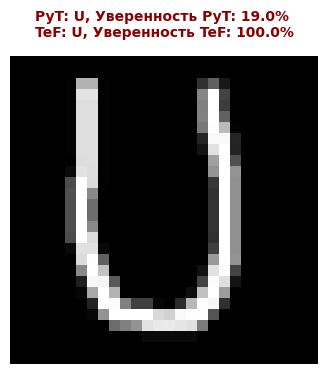

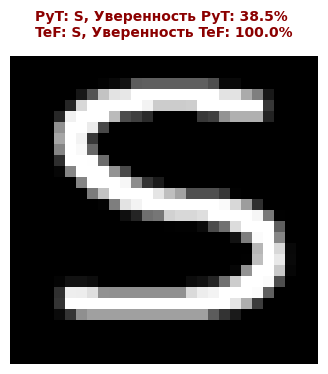

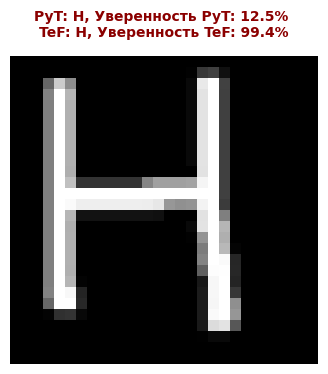

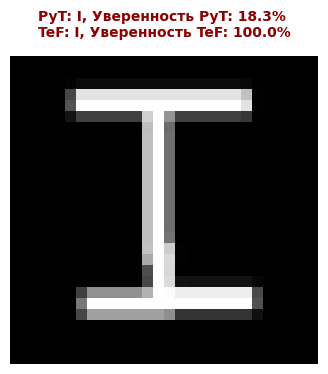

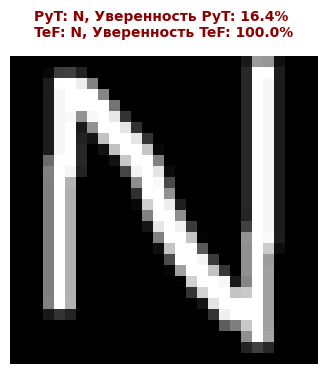

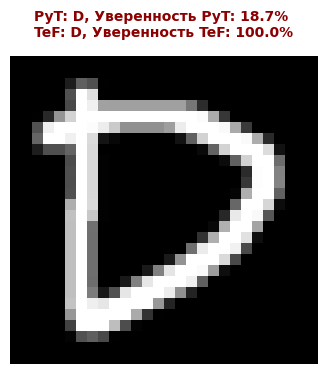

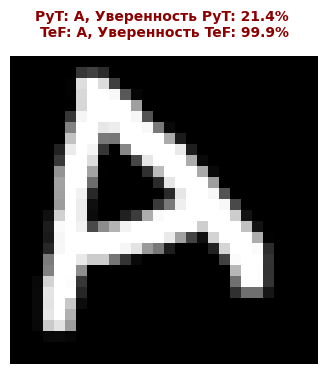

In [558]:
import os
import glob

image_folder = './data/My_img'
png_files = glob.glob(os.path.join(image_folder, '*.png'))


png_files.sort()

for file_path in png_files:

    
    filename = os.path.basename(file_path)

    var_1, var_2 = predict_letter(image_path=file_path)



## Отчёт о тестировании

## 1. Описание тестового набора данных и почерка

Для независимой проверки обученных моделей PyTorch и TensorFlow (Keras) в графическом редакторе были вручную нарисованы внешние изображения латинских букв: **G, R, U, S, H, I, N, D, A** (файлы сохранены в папке `./data/My_img/` в формате `.png` с прозрачным фоном). 


### 2. Анализ результатов распознавания

#### Успешные предсказания
* Обе модели безошибочно определили все буквы но с расной степенью уверенностью (более 90% для TensorFlow и 20% для PyTorch)


### 3. Ошибки и причины
В ходе детальной отладки были обнаружены две причины аномалий в предсказаниях:

1. **Поворот и отражение символов EMNIST**: Выяснилось, что оригинальный датасет EMNIST Letters хранит изображения в *транспонированном и зеркально отражённом виде*. Наша PyTorch-модель выучила именно такие «искажённые» буквы. В то же время, при обучении TensorFlow-модели был применёна трансформация `.transpose(0, 2, 1)`, которая *выпрямила* данные. 

2. **Артефакты альфа-канала (PNG)**: Прозрачный фон внешних файлов при базовой grayscale-конвертации превращался в чёрный шум, полностью стирая контуры букв. Проблема была решена принудительным наложением изображений на белую подложку `Image.new("RGB", ...)` перед обработкой. (решение честно взятое из интернетов)


### 4. Общий вывод по проекту

#### Что было самым сложным?
* Самым сложным оказалось - корректная подготовка данных для разных фреймворков. 
* Обнаружение в PNG прозрачного фона и работа с ним. 

#### Какой фреймворк понравился больше и почему?
* **TensorFlow (Keras)** понравился больше за счет того, что с его помощью проще выпонять прототипирование и настраивать быстрые модели для демонстрации заказчику. 

#### Что бы мы изменили, если бы делали проект снова?
1. Проектировал в рамках классов и ООП 
2. Выровнил входные данные для обеих моделей (сейчас одна училась на исходном датасете, для второй изображения были повернуты)
3. Не забыл бы использовать .copy при делении массивов на два варината обработки данных


In [ ]:
torch.save(PyT_model.state_dict(), 'PyT_model.pth')

TeF_model.save('TeF_model.h5')